## 🎮 Video Game Sales & Industry Data: EDA

---
**📌 Project Overview**: EDA & Get key finding from dataset
This project aims to analyze and visualize global video game sales data from 1980 to 2024. The analysis identifies key market trends, top-performing genres, and the relationship between game quality and revenue.

--- 
 **📊 Summary**

**1. Market Concentration**: To show how a small number of games and companies drive the industry. 
- The top 20% of games generate nearly 80% of total sales. Also, the top 10 publishers account for 58.7% of global sales, while the top 10 developers control about 33.33% of the market.

**2. Top Genres & Franchises**: To identify the leaders in the market. 
- Sports, Action, and Shooter are the top three genres. Grand Theft Auto V is the best-selling game of all time (double the sales of its closest rival). Call of Duty (from Activision publisher) dominates 9 of the top 10 Shooter list, and FIFA (from EA Sports publisher) holds almost all top spots in the Sports category.

**3. Platform Dominance & Trends**: To track the history of gaming hardware.
- Market sales peaked in 2008-2009. PlayStation (PS) is the long-term winner. Starting with the PS1 (61.25% market share in the 1990s), Sony has stayed on top. The PS2 is the best-selling console ever, with a 30.63% market share during the 2000s, followed by PS3 and PS4 in the digital era.

**4. Critic Scores vs. Commercial Success**: To see if good reviews lead to more money.
- The average game score is 7.3 out of 10. High scores do not always mean high sales, but low scores (below 5/10) almost always lead to poor sales. *(Note: Game Boy Color and Sandbox games like Minecraft have much higher scores than the market average)*.

---
**📚 Data Source**: [Video Game Sales & Industry Data (1980 - 2024)](https://www.kaggle.com/datasets/bhushandivekar/video-game-sales-and-industry-data-1980-2024?select=Video_Games_Sales_Cleaned.csv)

## Setup Environment

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load video game sales data from Kaggle and standardize column headers to snake_case.
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, 'bhushandivekar/video-game-sales-and-industry-data-1980-2024', 'Video_Games_Sales_Cleaned.csv')
df.columns = df.columns.str.lower().str.strip().str.replace(' ','_')

print(df.info())
print(df.isna().sum())


<class 'pandas.DataFrame'>
RangeIndex: 18832 entries, 0 to 18831
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         18832 non-null  str    
 1   console       18832 non-null  str    
 2   genre         18832 non-null  str    
 3   publisher     18832 non-null  str    
 4   developer     18832 non-null  str    
 5   critic_score  18832 non-null  float64
 6   total_sales   18832 non-null  float64
 7   release_year  18832 non-null  float64
dtypes: float64(3), str(5)
memory usage: 1.1 MB
None
title           0
console         0
genre           0
publisher       0
developer       0
critic_score    0
total_sales     0
release_year    0
dtype: int64


## Data Loading & Preprocessing

In [ ]:
# Change release_year column to datetime type
df['release_year'] = pd.to_datetime(df['release_year'], format='%Y')
print(df.info())
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 18832 entries, 0 to 18831
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   title         18832 non-null  str           
 1   console       18832 non-null  str           
 2   genre         18832 non-null  str           
 3   publisher     18832 non-null  str           
 4   developer     18832 non-null  str           
 5   critic_score  18832 non-null  float64       
 6   total_sales   18832 non-null  float64       
 7   release_year  18832 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(2), str(5)
memory usage: 1.1 MB
None


,title,console,genre,publisher,developer,critic_score,total_sales,release_year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,2013-01-01
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,2014-01-01
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,2002-01-01
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.3,15.86,2013-01-01
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,2015-01-01


## Sales Analysis

In [ ]:
# Setup function to build summary data frame
def sales_summary(data, group_col:str, group_cal:str):
    temp = data.groupby(group_col)[group_cal].sum().sort_values(ascending=False).reset_index()
    temp['sales_share'] = temp[group_cal] / temp[group_cal].sum()
    temp['pct'] = temp[group_cal].rank(pct=True)
    return temp


### 1. Best-Selling Video Games

Top 20% of sold games (2,596 games) contributed 79.83% of total sales
Top 10% of sold games (1,297 games) contributed 64.56% of total sales
Top 5% of sold games (647 games) contributed 49.70% of total sales
Top 1% of sold games (130 games) contributed 22.61% of total sales
Top 10 of 12935 games that contributed sold 7.61% of total sales


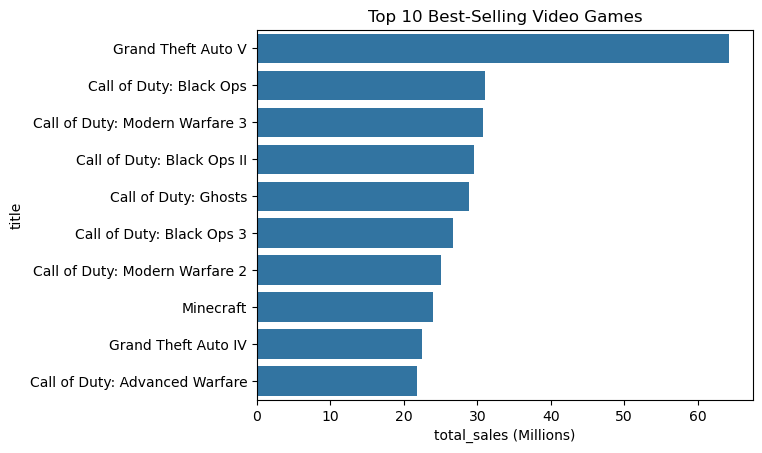

In [5]:
# Compute cumulative sales shares for top game percentiles and plot the top 10 best-selling games.
sales_title = sales_summary(df,'title','total_sales')

top_list = [.8,.9,.95,.99]
for i in top_list:
    count = sales_title.loc[sales_title['pct'] >= i, 'sales_share'].count()
    sales = sales_title.loc[sales_title['pct'] >= i, 'sales_share'].sum()
    print(f'Top {1-i:.0%} of sold games ({count:,d} games) contributed {sales:.2%} of total sales')

count = sales_title['title'].count()
sales = sales_title.loc[sales_title.index <= 20, 'sales_share'].sum()
print(f'Top 10 of {count} games that contributed sold {sales:.2%} of total sales')

sns.barplot(sales_title.head(10), x='total_sales', y='title')
plt.title('Top 10 Best-Selling Video Games')
plt.xlabel('total_sales (Millions)')
plt.show()


**Key Finding**
- Grand Theft Auto V is the best-selling game of all time, with total sales doubling those of its nearest competitor.

### 2. Sales Performance by Console

In [6]:
# Aggregate and display sales summary statistics for the top 10 gaming consoles.
sales_summary(df,'console','total_sales').head(10)


,console,total_sales,sales_share,pct
0,PS2,1025.38,0.155377,1.000000
1,X360,859.41,0.130227,0.974359
2,PS3,839.01,0.127136,0.948718
3,PS,546.21,0.082768,0.923077
4,PS4,539.92,0.081814,0.897436
5,Wii,458.92,0.069540,0.871795
6,DS,457.77,0.069366,0.846154
7,XOne,268.96,0.040756,0.820513
8,PSP,244.74,0.037086,0.794872
9,XB,232.05,0.035163,0.769231


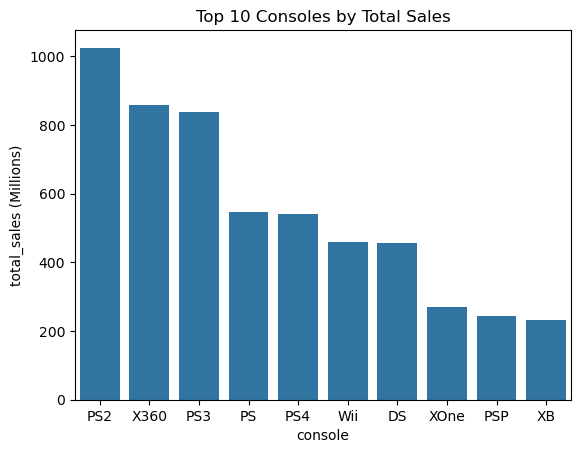

In [7]:
# Calculate top 10 console sales share and visualize their absolute contributions in a bar plot.
sales_console = sales_summary(df,'console','total_sales')

sales = sales_console.loc[sales_console.index <= 9, 'sales_share'].sum()

sns.barplot(sales_console.head(10), x='console', y='total_sales')
plt.ylabel('total_sales (Millions)')
plt.title('Top 10 Consoles by Total Sales')
plt.show()


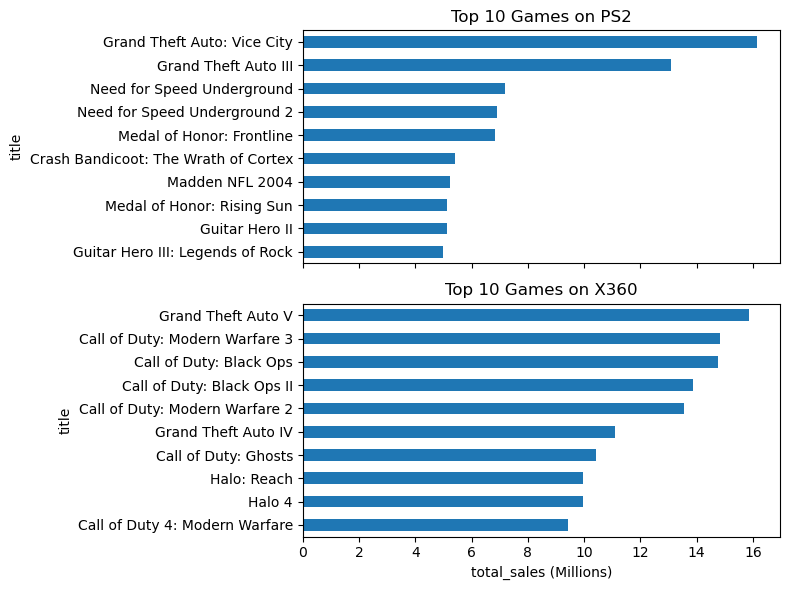

In [8]:
# Plot horizontal bar charts showing the top 10 best-selling games for the PS2 and Xbox 360.
fig, ax = plt.subplots(2,1, figsize=(8,6), sharex=True)

df[df['console'] == 'PS2'].groupby(['title'])['total_sales'].sum().sort_values(ascending=True).tail(10).plot.barh(ax=ax[0])
ax[0].set_title('Top 10 Games on PS2')

df[df['console'] == 'X360'].groupby(['title'])['total_sales'].sum().sort_values(ascending=True).tail(10).plot.barh(ax=ax[1])
ax[1].set_title('Top 10 Games on X360')

plt.xlabel('total_sales (Millions)')
plt.tight_layout()
plt.show()


**Key Finding**
- The top 10 consoles capture 83% of all sales, with PS2 being the best-selling platform.
- On PS2, GTA: Vice City is the top seller. However, Call of Duty performs better on the Xbox 360.

### 3. Market Share by Game Genre

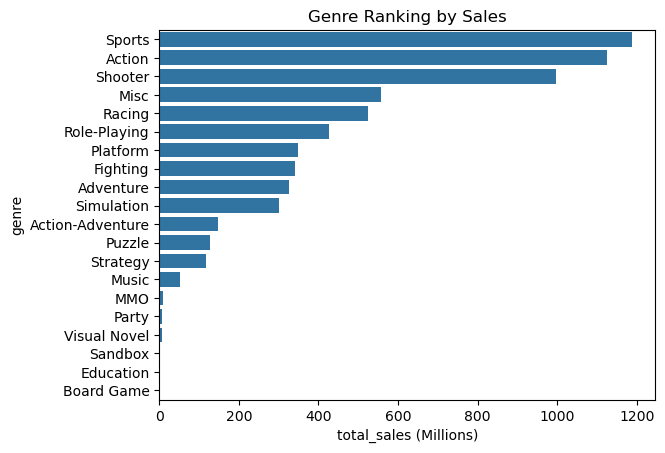

In [9]:
# Calculate sales summaries grouped by genre and plot their absolute sales figures.
sales_genre = sales_summary(df,'genre','total_sales')

sns.barplot(sales_genre, x='total_sales', y='genre')
plt.xlabel('total_sales (Millions)')
plt.title('Genre Ranking by Sales')
plt.show()


**Key Finding**
- Sports, Action, and Shooter dominate the market, with much higher sales than other genres.

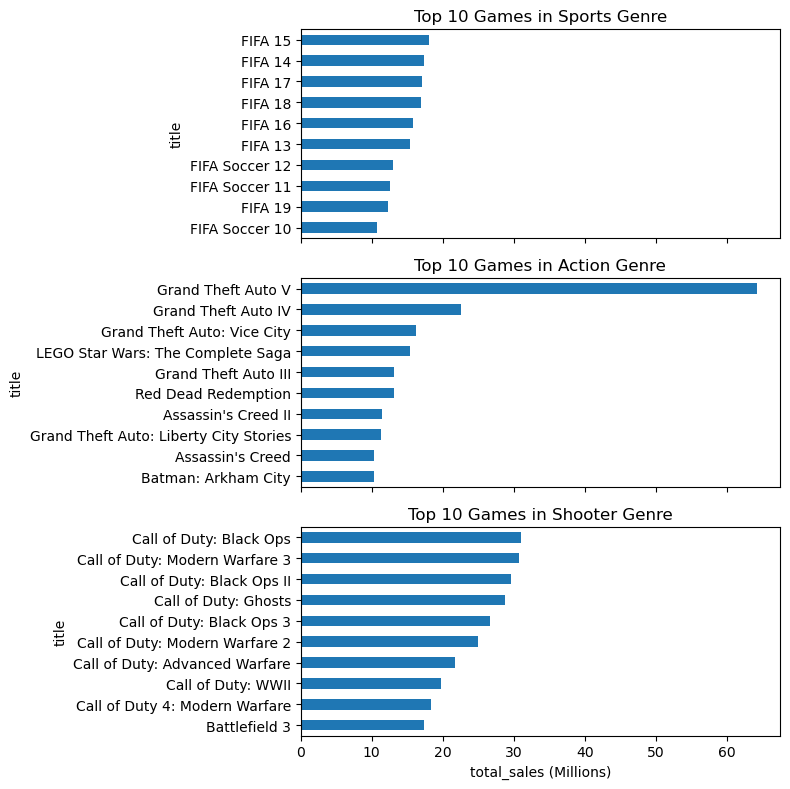

In [10]:
# Plot the top 10 best-selling games for the top three genres (Sports, Action, and Shooter).
fig, ax = plt.subplots(3,1, figsize=(8,8), sharex=True)

genre = ['Sports','Action','Shooter']

for i, genre in enumerate(genre):
    df[df['genre'] == genre].groupby(['title'])['total_sales'].sum().sort_values(ascending=True).tail(10).plot.barh(ax=ax[i])
    ax[i].set_xlabel('total_sales (Millions)')
    ax[i].set_title(f'Top 10 Games in {genre} Genre')

plt.tight_layout()
plt.show()


**Key Finding**

Analyzing the top 10 best-selling games for the leading genres:
- **Sports**: Every game in the top 10 is from the FIFA series.
- **Action**: Grand Theft Auto takes 5 out of the top 10 spots.
- **Shooter**: Call of Duty dominates with 9 out of the top 10 spots.

### 4. Top Publishers by Revenue

Top 10 of 739 publishers that contributed sold 58.73% of total sales


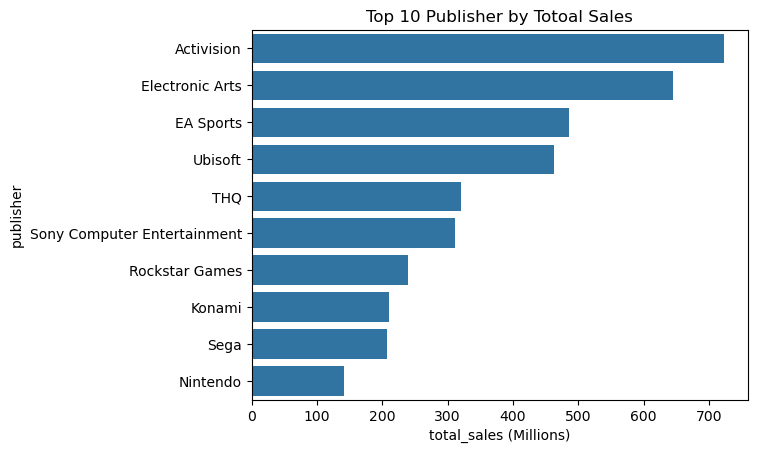

In [11]:
# Compute the total sales share of the top 10 publishers and plot their absolute sales.
sales_publisher = sales_summary(df,'publisher','total_sales')

count = sales_publisher['publisher'].count()
sales = sales_publisher.loc[sales_publisher.index <= 10, 'sales_share'].sum()
print(f'Top 10 of {count} publishers that contributed sold {sales:.2%} of total sales')

sns.barplot(sales_publisher.head(10), x='total_sales', y='publisher')
plt.xlabel('total_sales (Millions)')
plt.title('Top 10 Publisher by Totoal Sales')
plt.show()


**Key Finding**
- Over half of the global sales come from just the top 10 publishers.

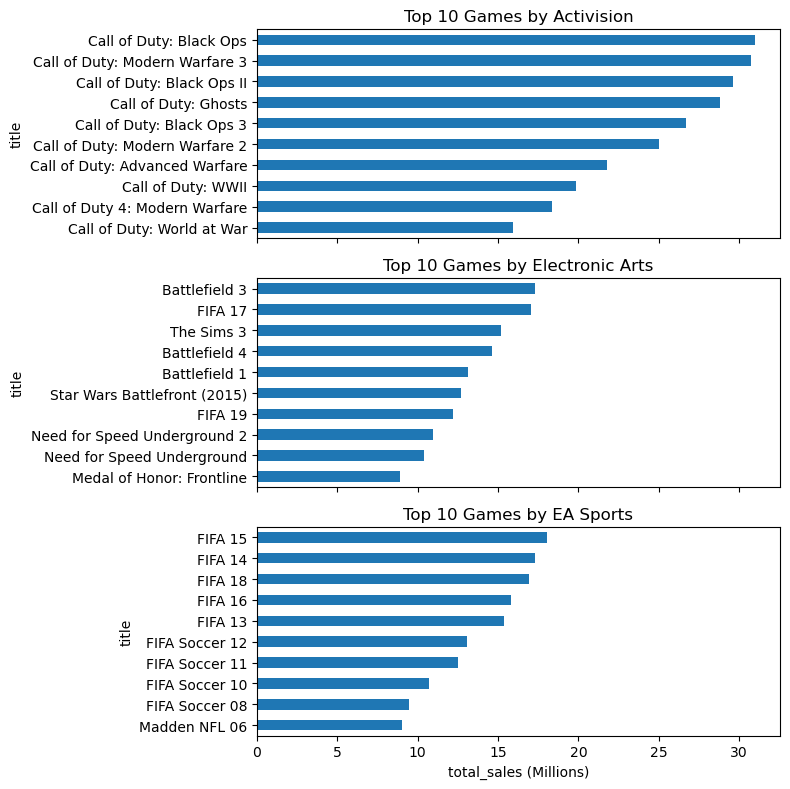

In [12]:
# Plot the top 10 best-selling games for Activision, Electronic Arts, and EA Sports.
fig, ax = plt.subplots(3,1, figsize=(8,8), sharex=True)

publisher = ['Activision','Electronic Arts','EA Sports']

for i, publisher in enumerate(publisher):
    df[df['publisher'] == publisher].groupby(['title'])['total_sales'].sum().sort_values(ascending=True).tail(10).plot.barh(ax=ax[i])
    ax[i].set_xlabel('total_sales (Millions)')
    ax[i].set_title(f'Top 10 Games by {publisher}')

plt.tight_layout()
plt.show()


**Key Finding**

Analyzing the top 10 best-selling games for the top 3 publishers:
- **Activision**: Call of Duty takes every spot in the top 10. 
- **Electronic Arts**: Battlefield is the top series, taking 3 spots in the top 10.
- **EA Sports**: FIFA dominates with 9 out of the top 10 spots.

### 5. Top Developers and Their Impact

Total developer : 2857
Top 20% of developers (572 developers) contributed 89.78% of total sales
Top 10% of developers (286 developers) contributed 78.78% of total sales
Top 5% of developers (144 developers) contributed 65.63% of total sales
Top 1% of developers (29 developers) contributed 36.34% of total sales
Top 10 of 2857 developers that contributed sold 31.58% of total sales


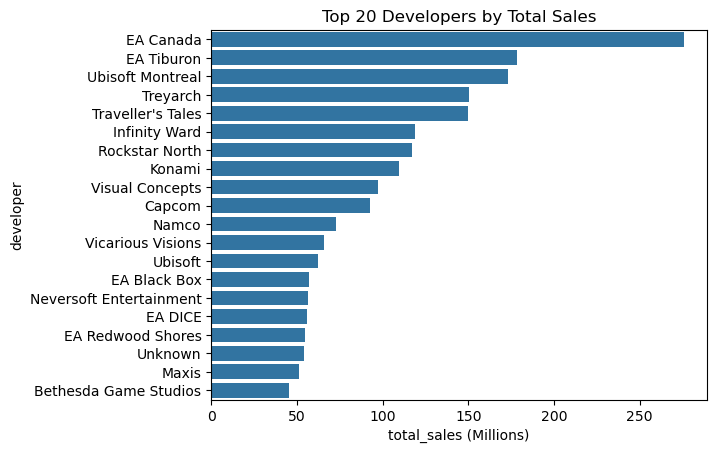

In [13]:
# Compute developer sales concentration metrics and plot the top 20 developers by total sales.
sales_developer = sales_summary(df,'developer','total_sales')

print(f'Total developer : {sales_developer['developer'].count()}')
top_list = [.8,.9,.95,.99]
for i in top_list:
    count = sales_developer.loc[sales_developer['pct'] >= i, 'sales_share'].count()
    sales = sales_developer.loc[sales_developer['pct'] >= i, 'sales_share'].sum()
    print(f'Top {1-i:.0%} of developers ({count:,d} developers) contributed {sales:.2%} of total sales')

count = sales_developer['developer'].count()
sales = sales_developer.loc[sales_developer.index <= 20, 'sales_share'].sum()
print(f'Top 10 of {count} developers that contributed sold {sales:.2%} of total sales')

sns.barplot(sales_developer.head(20), x='total_sales', y='developer')
plt.xlabel('total_sales (Millions)')
plt.title('Top 20 Developers by Total Sales')
plt.show()


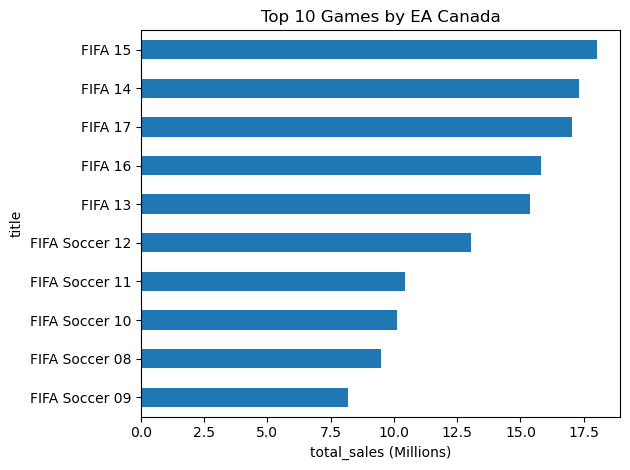

In [14]:
# Plot a horizontal bar chart of the top 10 best-selling games developed by EA Canada.
df[df['developer'] == 'EA Canada'].groupby(['title'])['total_sales'].sum().sort_values(ascending=True).tail(10).plot.barh()

plt.xlabel('total_sales (Millions)')
plt.title('Top 10 Games by EA Canada')

plt.tight_layout()
plt.show()


**Key Finding**
- The top 10 developers account for nearly 1/3 of all global sales.
- EA Canada is the #1 developer, with 55% higher sales than the second place.
- All of EA Canada's top 10 best-selling games are from the FIFA series.

## Score Analysis

In [ ]:
# Setup function to build summary data frame
def score_summary(data, group_col:str, group_cal:str):
    temp = data.groupby(group_col)[group_cal].mean().sort_values(ascending=False).reset_index()
    temp['pct'] = temp[group_cal].rank(pct=True)
    return temp


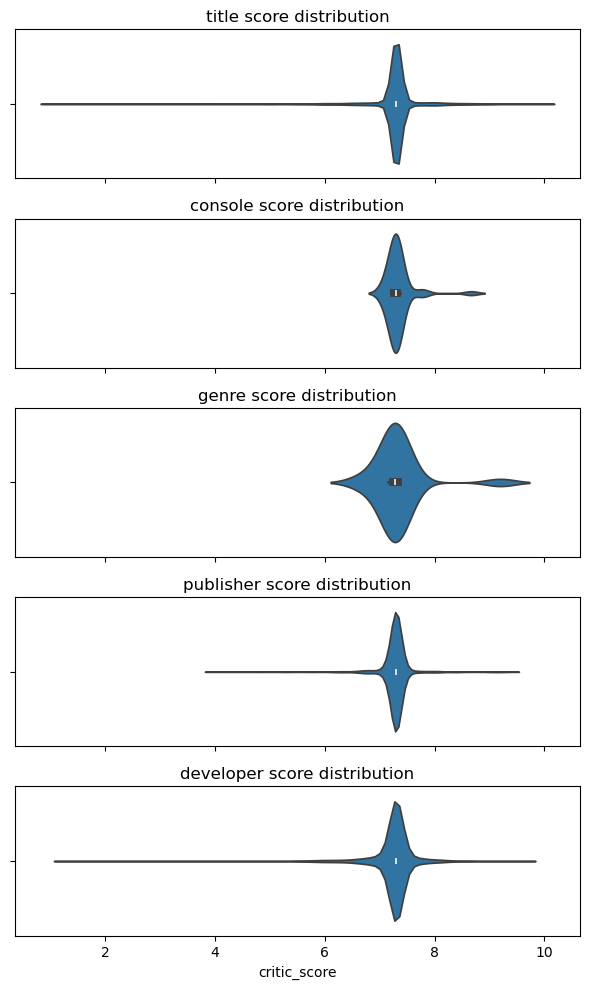

In [16]:
# Plot violin charts of critic score distributions across titles, consoles, genres, publishers, and developers.
fig, ax = plt.subplots(5,1, figsize=(6,10), sharex=True)

cate_list = ['title','console','genre','publisher','developer']

for i, cate in enumerate(cate_list):
    score = df.groupby(cate)['critic_score'].mean()
    sns.violinplot(x=score, ax=ax[i])
    ax[i].set_title(f'{cate} score distribution')

plt.tight_layout()
plt.show()


**Key Finding**
- Average scores are very similar across all categories (titles, consoles, genres, publishers, and developers), mostly clustering around 7.3.

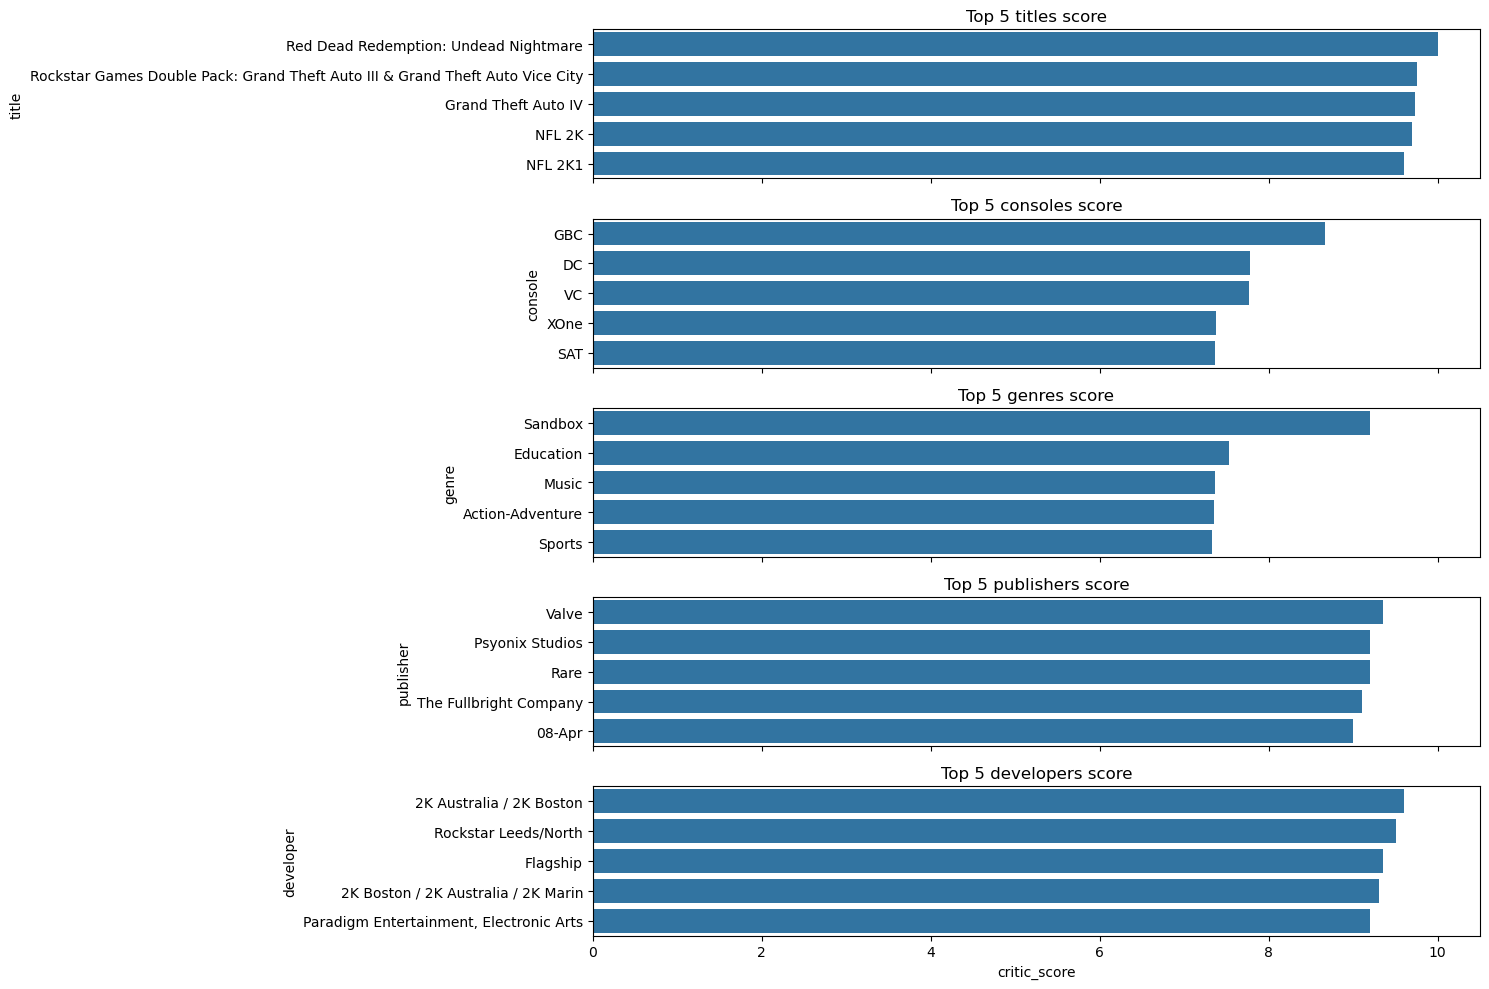

In [17]:
# Plot the top 5 highest average critic scores across five category breakdowns.
fig, ax = plt.subplots(5,1, figsize=(15,10), sharex=True)

cate_list = ['title','console','genre','publisher','developer']

for i, cate in enumerate(cate_list):
    top_5 = df.groupby(cate)['critic_score'].mean().nlargest(5).reset_index()
    sns.barplot(top_5, x='critic_score', y=cate, ax=ax[i])
    ax[i].set_title(f'Top 5 {cate}s score')

plt.tight_layout()
plt.show()


**Key Finding**
- Top scores are similar across most categories, except for Consoles and Genres.
- GBC (Game Boy Color) is the top console with a score of 8.67, which is 11% higher than the second place.
- Sandbox games have the highest score (9.2), which is 22% higher than the second place.

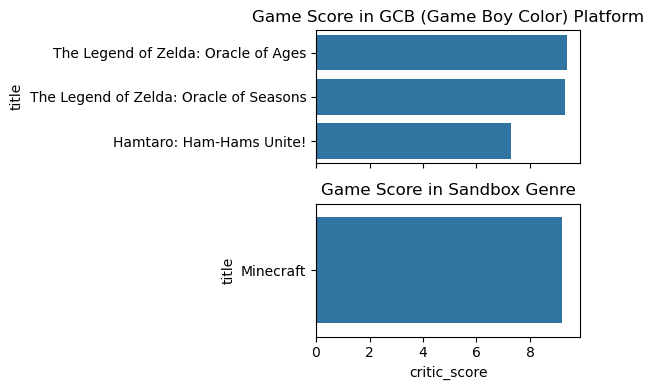

In [18]:
# Plot the top 5 games by critic score specifically for the Game Boy Color console and the Sandbox genre.
fig, ax = plt.subplots(2,1, figsize=(6,4), sharex=True)

cate_item = {
    'console':'GBC'
    , 'genre':'Sandbox'
}

for i, (cate, item) in enumerate(cate_item.items()):
    top_5 = df[df[cate] == item].groupby('title')['critic_score'].mean().nlargest(5).reset_index()
    sns.barplot(top_5, x='critic_score', y='title', ax=ax[i]) 

ax[0].set_title('Game Score in GCB (Game Boy Color) Platform')
ax[1].set_title('Game Score in Sandbox Genre')

plt.tight_layout()
plt.show()


**Key Finding**
- The top-rated games for GBC are The Legend of Zelda and Hamtaro.
- For the Sandbox genre, Minecraft is the top-rated game.

## Does High Quality Lead to High Sales?

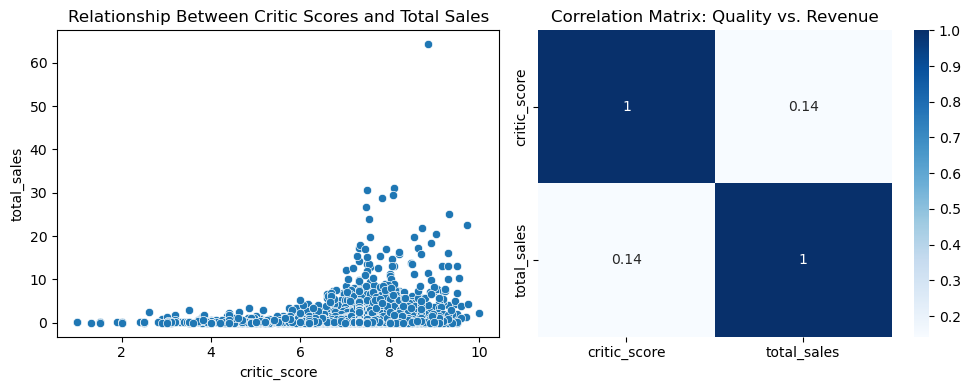

In [19]:
# Plot a scatter plot of Critic Scores vs. Total Sales alongside a correlation heatmap.
fig, ax = plt.subplots(1,2, figsize=(10,4))

sales_score = df.groupby('title').agg({
    'total_sales':'sum'
    , 'critic_score':'mean'
}).reset_index()

sns.scatterplot(sales_score, x='critic_score', y='total_sales', ax=ax[0])
ax[0].set_title('Relationship Between Critic Scores and Total Sales')

sns.heatmap(sales_score[['critic_score','total_sales']].corr(), annot=True, cmap='Blues')
ax[1].set_title('Correlation Matrix: Quality vs. Revenue')

plt.tight_layout()
plt.show()


**Key Finding**
- Game sales are not related to review scores. High-selling games can have both high and low scores.
- Games with scores below 5/10 usually have much lower sales than those with scores above 5.

## Market Trends Over Time (1980 - 2024)
- 1977 - 1989: The Early Years & Arcade Era (The beginning of video games and arcades.)
- 1990 - 1999: The 2D to 3D Revolution (The shift from 2D to 3D graphics, like PS1 and N64.)
- 2000 - 2009: The Golden Age of Consoles (The most popular era for consoles like PS2, Wii, and Xbox 360.)
- 2010 - 2020: The Modern & Digital Era (The focus on realistic graphics)

### 1. Console Sales by Era

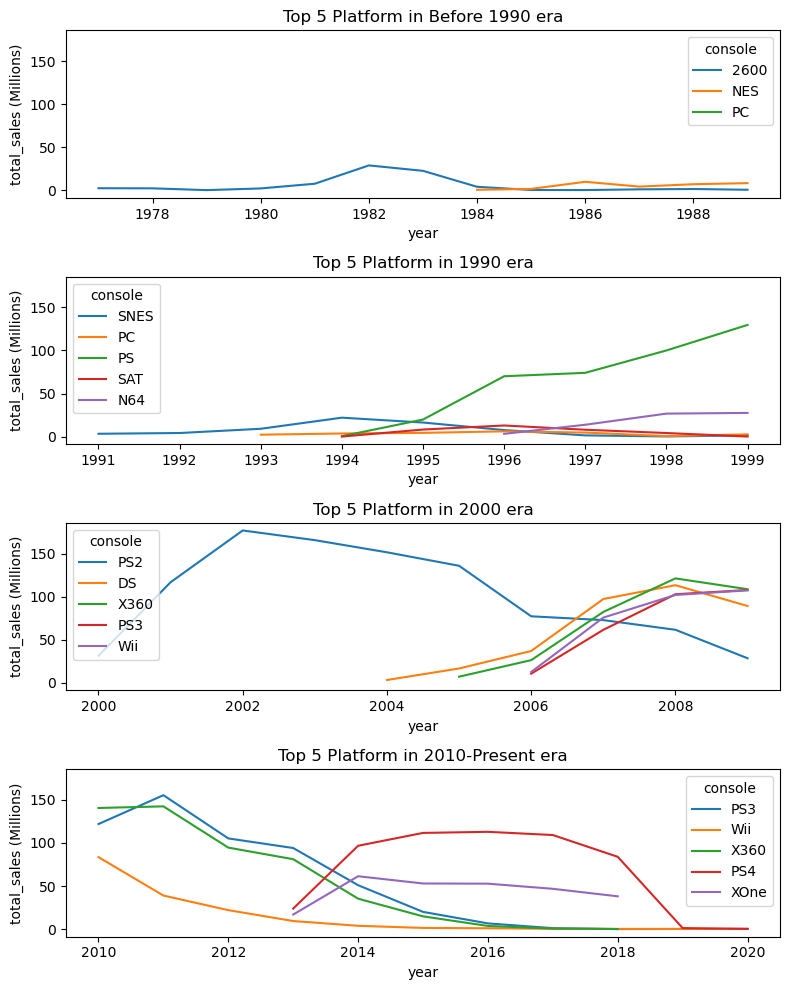

In [20]:
# Bin release years into historical eras (Before 1990, 1990s, 2000s, 2010-Present) and plot line graphs tracking sales trends for the top 5 consoles in each era.
df['year'] = df['release_year'].dt.year
df['era'] = pd.cut(
    df['year']
    , bins= [0,1989,1999,2009,2020]
    , labels= ['Before 1990','1990','2000','2010-Present']
)

year_console_top = df.groupby(['era','year','console'])['total_sales'].sum().reset_index()
era = ['Before 1990','1990','2000','2010-Present']

fig, ax = plt.subplots(4,1, figsize=(8,10), sharey=True)
for i, era in enumerate(era) :
    top_5 = year_console_top[year_console_top['era'] == era].groupby('console')['total_sales'].sum().nlargest(5).index
    sns.lineplot(
        year_console_top[(year_console_top['era'] == era) & (year_console_top['console'].isin(top_5))]
        , x='year'
        , y='total_sales'
        , hue='console'
        , ax=ax[i]
        , estimator='sum'
    )
    ax[i].set_title(f'Top 5 Platform in {era} era')
    ax[i].set_ylabel('total_sales (Millions)')

plt.tight_layout()
plt.show()


**Key Finding**

Sales by Era and Platform:
- **Before 1990 era**: Sales were low 107.66 Millions (only 1.63% of total era). 2600 (Atari 2600) and 3DO (3DO Interactive Multiplayer) were the main platforms.
- **1990 era**: PS (PlayStation) changed the market, taking a huge 394.22 Millions (61.25% share of all sales in this era).
- **2000 era**: Many new platforms appeared like DS, Wii, and Xbox 360. However, PS remained the market leader. PS2 held a 30.63% share, while PS3 sales also grew before leading the next era.
- **2010 - Present**: PS still leads the market. Combined sales of PS3 and PS4 are the highest, followed by Xbox 360.

### 2. Sales Trends: Top Genres & Publishers

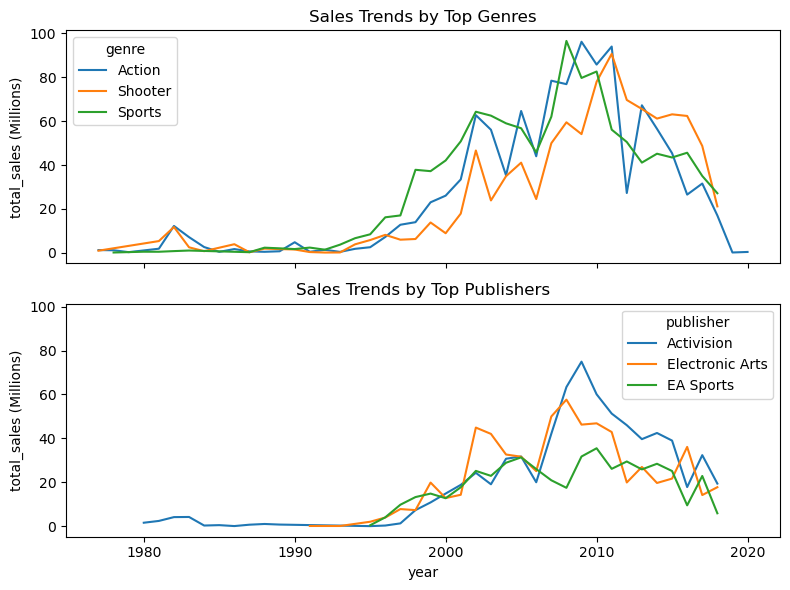

In [21]:
# Plot line charts tracking annual sales trends for the top 3 genres and top 3 publishers.
fig, ax = plt.subplots(2,1,figsize=(8,6), sharex=True, sharey=True)

top_5_genre = df.groupby('genre')['total_sales'].sum().nlargest(3).index
year_genre = df[df['genre'].isin(top_5_genre)].groupby(['year','genre'])['total_sales'].sum().reset_index()
sns.lineplot(year_genre, x='year', y='total_sales', hue='genre', ax=ax[0])
ax[0].set_title('Sales Trends by Top Genres')
ax[0].set_ylabel('total_sales (Millions)')

top_5_publisher = df.groupby('publisher')['total_sales'].sum().nlargest(3).index
year_publisher = df[df['publisher'].isin(top_5_publisher)].groupby(['year','publisher'])['total_sales'].sum().reset_index()
sns.lineplot(year_publisher, x='year', y='total_sales', hue='publisher', ax=ax[1])
ax[1].set_title('Sales Trends by Top Publishers')
ax[1].set_ylabel('total_sales (Millions)')

plt.tight_layout()
plt.show()


**Key Finding**
- Sales for all genres grew rapidly after 2000 and peaked between 2008 and 2009.
- After 2005, Activision saw a huge jump in sales compared to its steady growth in previous years.
- While Activision shows a huge jump, Electronic Arts (EA) is the true leader. Since EA holds both the #2 and #3 ranks, their combined sales are actually higher than Activision's.